Dataset directory: D:\traffic-sign-recogonition\dataset
Training labels: D:\traffic-sign-recogonition\dataset\Train.csv
Fixed image size: (32, 32)
Training records: 39209
Number of classes: 43
Class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]
Images per class:


,ImageCount
ClassId,
0,210
1,2220
2,2250
3,1410
4,1980
5,1860
6,420
7,1440
8,1410


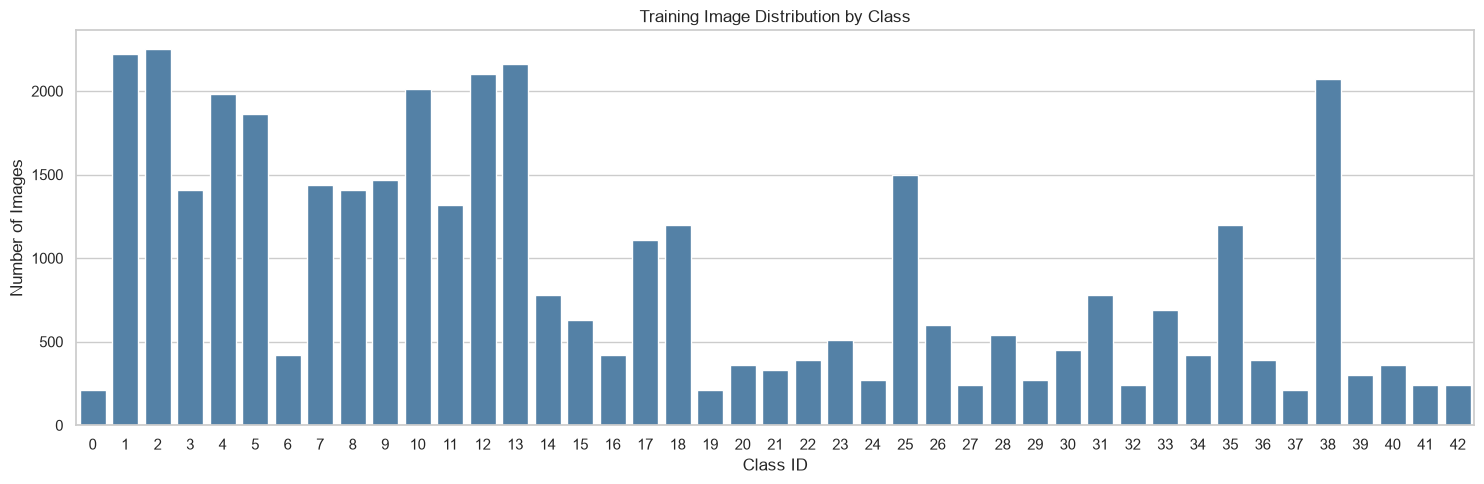

Training split records: 31367
Validation split records: 7842
Training proportion: 0.7999948991303018
Validation proportion: 0.20000510086969828
Images loaded and normalized.
X_train shape: (31367, 32, 32, 3)
y_train shape: (31367,)
X_val shape: (7842, 32, 32, 3)
y_val shape: (7842,)
X_train dtype: float32
X_val dtype: float32
Training pixel range: (0.0, 1.0)
Validation pixel range: (0.0, 1.0)
All 43 classes in training split: True
All 43 classes in validation split: True
Missing training classes: []
Missing validation classes: []

Stratified class-count check:


,Training,Validation
0,168,42
1,1776,444
2,1800,450
3,1128,282
4,1584,396
5,1488,372
6,336,84
7,1152,288
8,1128,282
9,1176,294


Test data was kept separate: no test images were loaded or modified.

Summary
Training samples: 31367
Validation samples: 7842
Number of classes: 43
Image shape: (32, 32, 3)
Pixel range: (0.0, 1.0)
Random state: 42
Validation split: 20%
CNN training and augmentation were not performed.
Training data: (31367, 32, 32, 3) (31367,)
Validation data: (7842, 32, 32, 3) (7842,)
Number of classes: 43


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

RANDOM_STATE = 42
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 43

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = NOTEBOOK_DIR / "notebooks"
PREPARATION_NOTEBOOK = NOTEBOOK_DIR / "02_data_preparation.ipynb"
if not PREPARATION_NOTEBOOK.exists():
    raise FileNotFoundError(f"Preparation notebook was not found: {PREPARATION_NOTEBOOK}")

# Reuse the prepared X_train, y_train, X_val, and y_val variables from notebook 02.
get_ipython().run_line_magic("run", str(PREPARATION_NOTEBOOK))

if "X_train" not in globals() or "y_train" not in globals():
    raise RuntimeError("Notebook 02 did not create the training split.")
if "X_val" not in globals() or "y_val" not in globals():
    raise RuntimeError("Notebook 02 did not create the validation split.")

assert X_train.shape[1:] == (32, 32, 3)
assert X_val.shape[1:] == (32, 32, 3)
assert len(np.unique(y_train)) == NUM_CLASSES
assert len(np.unique(y_val)) == NUM_CLASSES

print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_val.shape, y_val.shape)
print("Number of classes:", NUM_CLASSES)

In [2]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    horizontal_flip=False,
    fill_mode="nearest",
)

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_STATE,
)

print("Training augmentation configured.")
print("Validation augmentation: disabled")

Training augmentation configured.
Validation augmentation: disabled


In [3]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.50),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,067 (1.38 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    verbose=1,
)

print("Training complete.")

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.3355 - loss: 2.2933 - val_accuracy: 0.6811 - val_loss: 0.9954
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.6627 - loss: 1.0086 - val_accuracy: 0.8942 - val_loss: 0.3256
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - accuracy: 0.7967 - loss: 0.5999 - val_accuracy: 0.9491 - val_loss: 0.1728
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.8600 - loss: 0.4152 - val_accuracy: 0.9700 - val_loss: 0.1020
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 83s 85ms/step - accuracy: 0.8929 - loss: 0.3204 - val_accuracy: 0.9841 - val_loss: 0.0605
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.9202 - loss: 0.2439 - val_accuracy: 0.9818 - val_loss: 0.0606
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.9314 - loss: 0.2124 - val_accuracy: 0.9852 - val_loss: 0.0427
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9416 - loss: 0.1786 - 

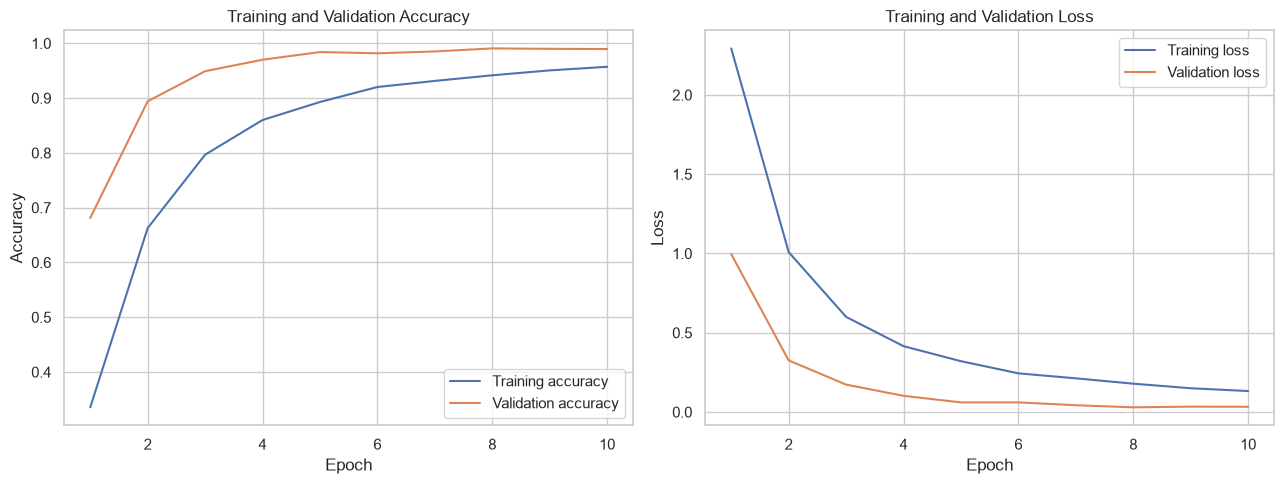

In [5]:
history_values = history.history
epochs = range(1, len(history_values["accuracy"]) + 1)

figure, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs, history_values["accuracy"], label="Training accuracy")
axes[0].plot(epochs, history_values["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history_values["loss"], label="Training loss")
axes[1].plot(epochs, history_values["val_loss"], label="Validation loss")
axes[1].set_title("Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

figure.tight_layout()
plt.show()

In [6]:
PROJECT_ROOT = NOTEBOOK_DIR.parent
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "traffic_sign_cnn.keras"

model.save(MODEL_PATH)
print(f"Saved trained model to: {MODEL_PATH.resolve()}")

Saved trained model to: D:\traffic-sign-recogonition\models\traffic_sign_cnn.keras
